Random Forest - validação cruzada baseline
   fold  accuracy  precision    recall        f1
0     1  0.862458   0.870968  0.851351  0.861048
1     2  0.856821   0.879808  0.826185  0.852154
2     3  0.859076   0.850220  0.871332  0.860647
3     4  0.851184   0.854214  0.846501  0.850340
4     5  0.852144   0.862791  0.837472  0.849943

Médias da validação cruzada - Random Forest baseline
accuracy     0.856336
precision    0.863600
recall       0.846568
f1           0.854826
dtype: float64

Desvios-padrão da validação cruzada - Random Forest baseline
accuracy     0.004726
precision    0.012091
recall       0.016840
f1           0.005561
dtype: float64
Fitting 5 folds for each of 324 candidates, totalling 1620 fits

Melhores hiperparâmetros - Random Forest
{'rf__max_depth': None, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 5, 'rf__n_estimators': 300}

Melhor F1 médio em validação cruzada - Random Forest
0.8573848121805892

Random Forest otimizada
Accur

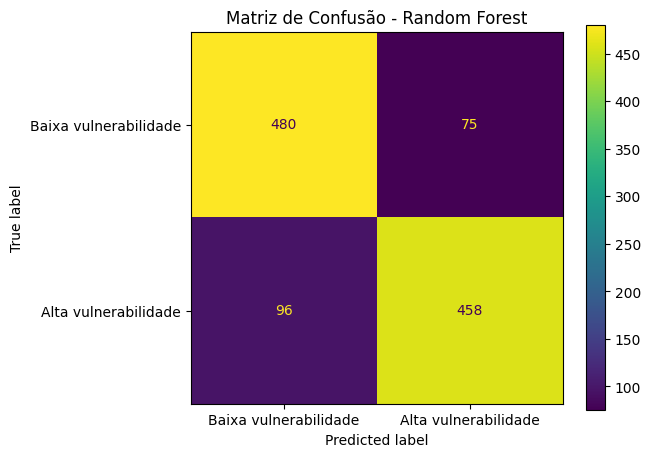


F1 por fold - Random Forest otimizada
   fold        f1
0     1  0.864926
1     2  0.858810
2     3  0.861265
3     4  0.852608
4     5  0.849315

Média F1 por fold - Random Forest otimizada
0.8573848121805892

Desvio-padrão F1 por fold - Random Forest otimizada
0.0063620512097641736

Comparação final entre todos os modelos
                 Modelo  Accuracy  Precision    Recall  F1-score
0            Perceptron  0.796213   0.787719  0.810469  0.798932
1  Árvore não otimizada  0.779982   0.781818  0.776173  0.778986
2      Árvore otimizada  0.834085   0.850379  0.810469  0.829945
3         Random Forest  0.845807   0.859287  0.826715  0.842686


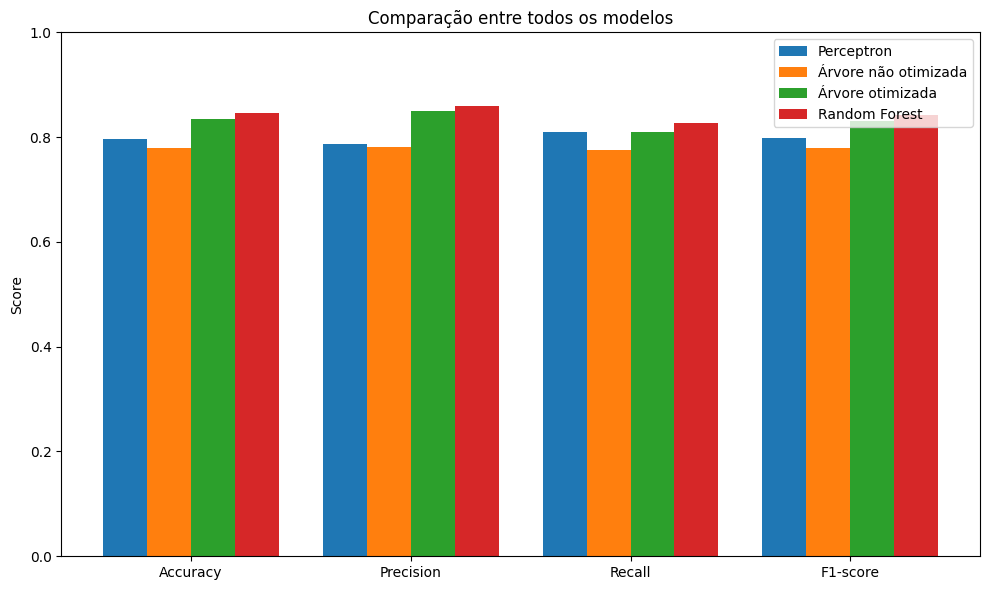

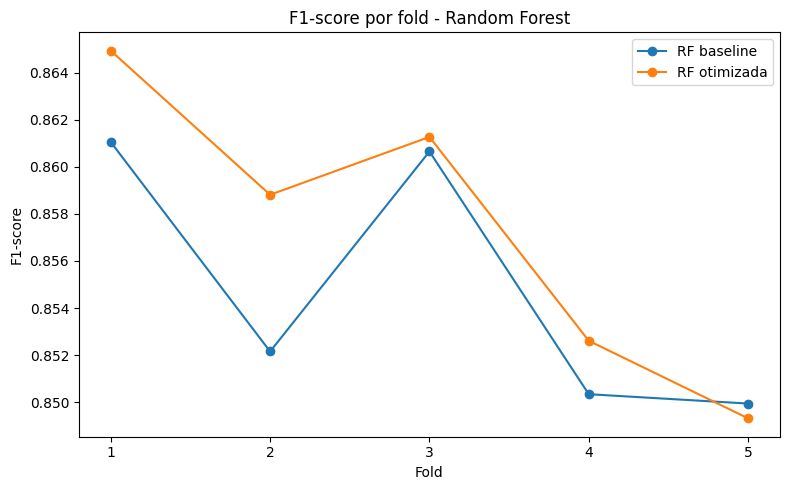

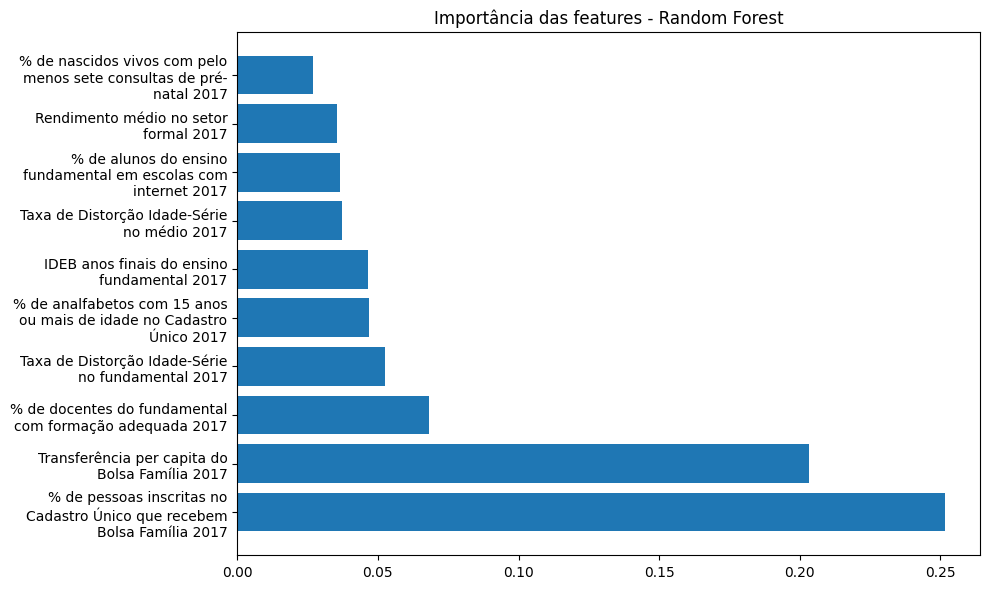


Top 10 features mais importantes - Random Forest
                                              feature  importance
15  % de pessoas inscritas no Cadastro Único que r...    0.251492
6      Transferência per capita do Bolsa Família 2017    0.203401
4   % de docentes do fundamental com formação adeq...    0.068101
0   Taxa de Distorção Idade-Série no fundamental 2017    0.052649
14  % de analfabetos com 15 anos ou mais de idade ...    0.046887
2         IDEB anos finais do ensino fundamental 2017    0.046539
1         Taxa de Distorção Idade-Série no médio 2017    0.037266
3   % de alunos do ensino fundamental em escolas c...    0.036385
5               Rendimento médio no setor formal 2017    0.035465
9   % de nascidos vivos com pelo menos sete consul...    0.026797

Número de árvores no ensemble: 300

Profundidade máxima permitida: None
min_samples_split: 5
min_samples_leaf: 2
max_features: sqrt

Profundidade média das árvores do ensemble: 19.51
Profundidade mínima das árvores do ensem

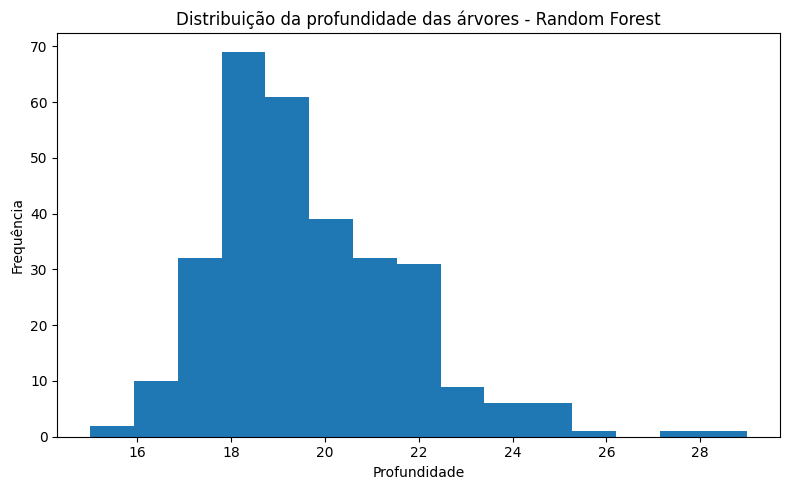

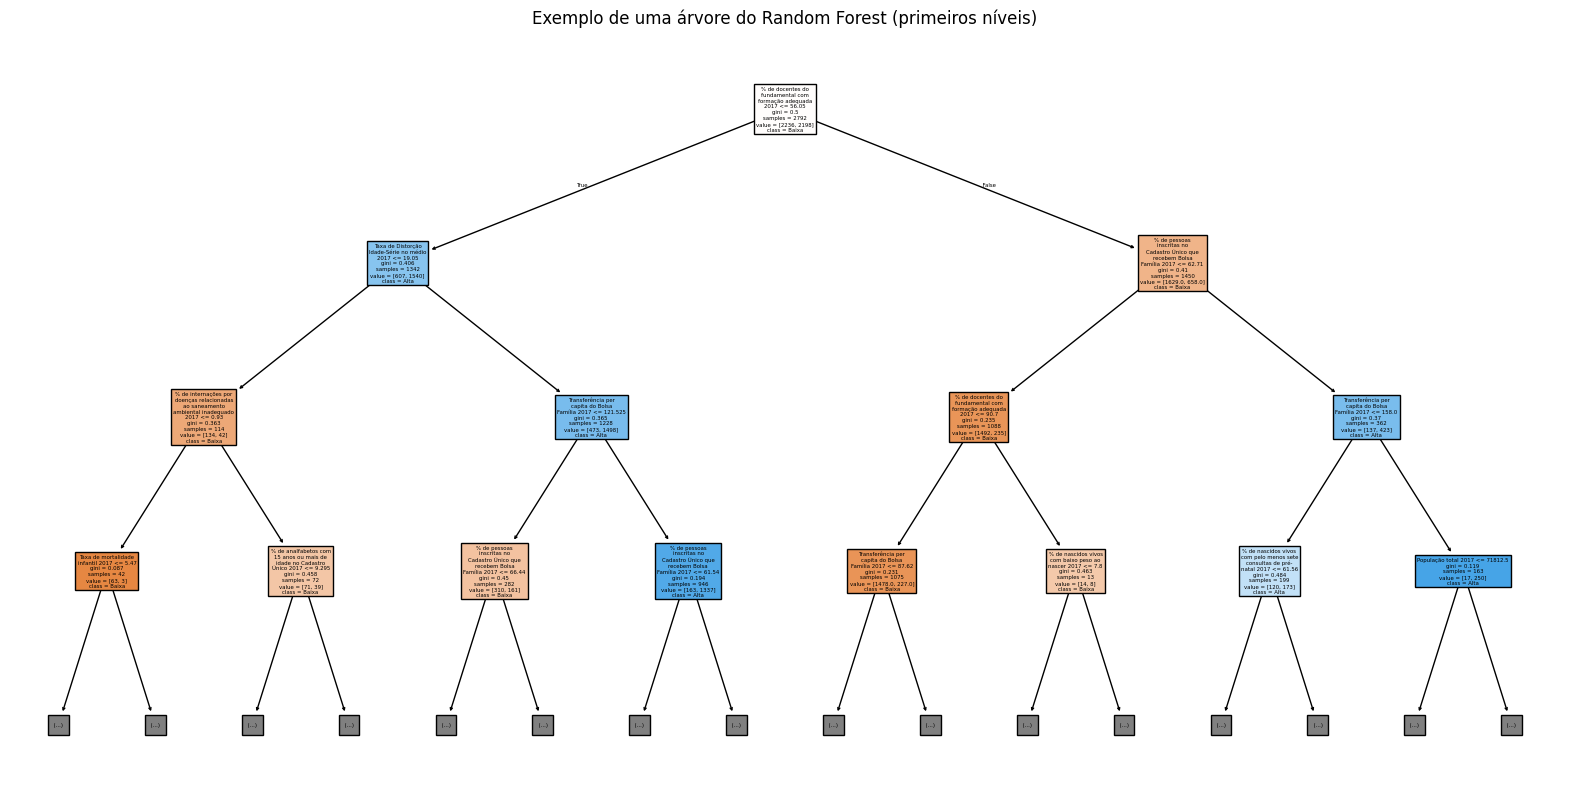

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import textwrap

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

CSV_PATH = "../data/censo_municipal.csv"
ID_COL = "Territorialidades"
TARGET_SOURCE_COL = "% de extremamente pobres no Cadastro Único pós Bolsa Família 2017"
TEST_SIZE = 0.20
RANDOM_STATE = 42

def wrap_labels(labels, width=30):
    return [textwrap.fill(label, width) for label in labels]

df = pd.read_csv(CSV_PATH)

for col in df.columns:
    if col != ID_COL:
        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
            .str.replace("%", "", regex=False)
            .str.replace(".", "", regex=False)
            .str.replace(",", ".", regex=False)
            .replace(["nan", "None", ""], np.nan)
        )
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=[TARGET_SOURCE_COL]).copy()

threshold = df[TARGET_SOURCE_COL].median()
df["vulnerabilidade_alta"] = (df[TARGET_SOURCE_COL] > threshold).astype(int)

drop_cols = [ID_COL, TARGET_SOURCE_COL, "vulnerabilidade_alta"]

X = df.drop(columns=drop_cols).copy()
y = df["vulnerabilidade_alta"].copy()

X = X.select_dtypes(include=[np.number]).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

perceptron_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("perceptron", Perceptron(max_iter=1000, tol=1e-3, random_state=RANDOM_STATE))
])

perceptron_model.fit(X_train, y_train)
perceptron_pred = perceptron_model.predict(X_test)

perceptron_acc = accuracy_score(y_test, perceptron_pred)
perceptron_prec = precision_score(y_test, perceptron_pred)
perceptron_rec = recall_score(y_test, perceptron_pred)
perceptron_f1 = f1_score(y_test, perceptron_pred)

tree_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("tree", DecisionTreeClassifier(random_state=RANDOM_STATE))
])

tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)

tree_acc = accuracy_score(y_test, tree_pred)
tree_prec = precision_score(y_test, tree_pred)
tree_rec = recall_score(y_test, tree_pred)
tree_f1 = f1_score(y_test, tree_pred)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

tree_param_grid = {
    "tree__criterion": ["gini", "entropy"],
    "tree__max_depth": [3, 5, 8, 10, 15, None],
    "tree__min_samples_split": [2, 5, 10, 20],
    "tree__min_samples_leaf": [1, 2, 5, 10],
    "tree__ccp_alpha": [0.0, 0.0005, 0.001, 0.005, 0.01]
}

tree_grid = GridSearchCV(
    estimator=tree_model,
    param_grid=tree_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=0
)

tree_grid.fit(X_train, y_train)
optimized_tree_model = tree_grid.best_estimator_
optimized_tree_pred = optimized_tree_model.predict(X_test)

optimized_tree_acc = accuracy_score(y_test, optimized_tree_pred)
optimized_tree_prec = precision_score(y_test, optimized_tree_pred)
optimized_tree_rec = recall_score(y_test, optimized_tree_pred)
optimized_tree_f1 = f1_score(y_test, optimized_tree_pred)

rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("rf", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

rf_baseline_cv = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

rf_baseline_cv_df = pd.DataFrame({
    "fold": np.arange(1, 6),
    "accuracy": rf_baseline_cv["test_accuracy"],
    "precision": rf_baseline_cv["test_precision"],
    "recall": rf_baseline_cv["test_recall"],
    "f1": rf_baseline_cv["test_f1"]
})

print("Random Forest - validação cruzada baseline")
print(rf_baseline_cv_df)

print("\nMédias da validação cruzada - Random Forest baseline")
print(rf_baseline_cv_df[["accuracy", "precision", "recall", "f1"]].mean())

print("\nDesvios-padrão da validação cruzada - Random Forest baseline")
print(rf_baseline_cv_df[["accuracy", "precision", "recall", "f1"]].std())

rf_param_grid = {
    "rf__n_estimators": [100, 200, 300],
    "rf__max_depth": [5, 10, 15, None],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf": [1, 2, 5],
    "rf__max_features": ["sqrt", "log2", None]
}

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1
)

rf_grid.fit(X_train, y_train)

best_rf_model = rf_grid.best_estimator_
best_rf_params = rf_grid.best_params_
best_rf_cv_score = rf_grid.best_score_

print("\nMelhores hiperparâmetros - Random Forest")
print(best_rf_params)

print("\nMelhor F1 médio em validação cruzada - Random Forest")
print(best_rf_cv_score)

rf_pred = best_rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred)
rf_rec = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("\nRandom Forest otimizada")
print("Accuracy:", rf_acc)
print("Precision:", rf_prec)
print("Recall:", rf_rec)
print("F1-score:", rf_f1)

print("\nClassification Report - Random Forest")
print(classification_report(y_test, rf_pred))

cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Baixa vulnerabilidade", "Alta vulnerabilidade"]
)
disp.plot(ax=plt.gca(), values_format="d")
plt.title("Matriz de Confusão - Random Forest")
plt.grid(False)
plt.show()

rf_cv_results_df = pd.DataFrame(rf_grid.cv_results_)
best_rf_index = rf_grid.best_index_

rf_best_fold_columns = [col for col in rf_cv_results_df.columns if col.startswith("split") and col.endswith("_test_score")]
rf_best_fold_scores = rf_cv_results_df.loc[best_rf_index, rf_best_fold_columns].values.astype(float)

rf_optimized_cv_df = pd.DataFrame({
    "fold": np.arange(1, len(rf_best_fold_scores) + 1),
    "f1": rf_best_fold_scores
})

print("\nF1 por fold - Random Forest otimizada")
print(rf_optimized_cv_df)

print("\nMédia F1 por fold - Random Forest otimizada")
print(rf_optimized_cv_df["f1"].mean())

print("\nDesvio-padrão F1 por fold - Random Forest otimizada")
print(rf_optimized_cv_df["f1"].std())

comparison_df = pd.DataFrame({
    "Modelo": ["Perceptron", "Árvore não otimizada", "Árvore otimizada", "Random Forest"],
    "Accuracy": [perceptron_acc, tree_acc, optimized_tree_acc, rf_acc],
    "Precision": [perceptron_prec, tree_prec, optimized_tree_prec, rf_prec],
    "Recall": [perceptron_rec, tree_rec, optimized_tree_rec, rf_rec],
    "F1-score": [perceptron_f1, tree_f1, optimized_tree_f1, rf_f1]
})

print("\nComparação final entre todos os modelos")
print(comparison_df)

metrics_names = ["Accuracy", "Precision", "Recall", "F1-score"]
perceptron_metrics = [perceptron_acc, perceptron_prec, perceptron_rec, perceptron_f1]
tree_metrics = [tree_acc, tree_prec, tree_rec, tree_f1]
optimized_tree_metrics = [optimized_tree_acc, optimized_tree_prec, optimized_tree_rec, optimized_tree_f1]
rf_metrics = [rf_acc, rf_prec, rf_rec, rf_f1]

x = np.arange(len(metrics_names))
width = 0.2

plt.figure(figsize=(10, 6))
plt.bar(x - 1.5 * width, perceptron_metrics, width, label="Perceptron")
plt.bar(x - 0.5 * width, tree_metrics, width, label="Árvore não otimizada")
plt.bar(x + 0.5 * width, optimized_tree_metrics, width, label="Árvore otimizada")
plt.bar(x + 1.5 * width, rf_metrics, width, label="Random Forest")
plt.xticks(x, metrics_names)
plt.ylim(0, 1)
plt.title("Comparação entre todos os modelos")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(rf_baseline_cv_df["fold"], rf_baseline_cv_df["f1"], marker="o", label="RF baseline")
plt.plot(rf_optimized_cv_df["fold"], rf_optimized_cv_df["f1"], marker="o", label="RF otimizada")
plt.xticks(np.arange(1, 6))
plt.title("F1-score por fold - Random Forest")
plt.xlabel("Fold")
plt.ylabel("F1-score")
plt.legend()
plt.tight_layout()
plt.show()

rf_model = best_rf_model.named_steps["rf"]

rf_importances = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

top_rf_importances = rf_importances.head(10)

plt.figure(figsize=(10, 6))
plt.barh(wrap_labels(top_rf_importances["feature"]), top_rf_importances["importance"])
plt.title("Importância das features - Random Forest")
plt.tight_layout()
plt.show()

print("\nTop 10 features mais importantes - Random Forest")
print(top_rf_importances)

print("\nNúmero de árvores no ensemble:", rf_model.n_estimators)

print("\nProfundidade máxima permitida:", rf_model.max_depth)
print("min_samples_split:", rf_model.min_samples_split)
print("min_samples_leaf:", rf_model.min_samples_leaf)
print("max_features:", rf_model.max_features)

tree_depths = [est.get_depth() for est in rf_model.estimators_]
tree_leaves = [est.get_n_leaves() for est in rf_model.estimators_]

print("\nProfundidade média das árvores do ensemble:", np.mean(tree_depths))
print("Profundidade mínima das árvores do ensemble:", np.min(tree_depths))
print("Profundidade máxima das árvores do ensemble:", np.max(tree_depths))

print("\nNúmero médio de folhas por árvore:", np.mean(tree_leaves))
print("Número mínimo de folhas por árvore:", np.min(tree_leaves))
print("Número máximo de folhas por árvore:", np.max(tree_leaves))

plt.figure(figsize=(8, 5))
plt.hist(tree_depths, bins=15)
plt.title("Distribuição da profundidade das árvores - Random Forest")
plt.xlabel("Profundidade")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 10))
sample_tree = rf_model.estimators_[0]
from sklearn.tree import plot_tree
plot_tree(
    sample_tree,
    feature_names=wrap_labels(X.columns, 20),
    class_names=["Baixa", "Alta"],
    filled=True,
    max_depth=3
)
plt.title("Exemplo de uma árvore do Random Forest (primeiros níveis)")
plt.show()